# Two-country IRBC with irreversible investment — multipliers as policies

**Day 3** of the Geneva 2026 *Deep Learning for Economics & Finance* course: a
two-country International Real Business Cycle model solved as a planner problem.
Three method lessons beyond the Brock-Mirman family:

1. **KKT multipliers are network outputs.** Investment in each country is
   irreversible, $i_j \ge 0$. In `bm_labor_constrained` the complementarity
   wedge was an analytic expression; here the multipliers $\mu_j$ (and the
   aggregate shadow price $\lambda$) are *learned policies*, paired with their
   constraints through Fischer-Burmeister residuals
   $f^{FB}(\mu_j, i_j) = \mu_j + i_j - \sqrt{\mu_j^2 + i_j^2}$.
2. **Consumption is pinned, not learned.** Complete markets + Pareto weights
   $\tau_j$ give marginal-utility equalization
   $c_j = (\lambda/\tau_j)^{-1/\gamma_j}$ — the network never outputs
   consumption; the FOC structure does.
3. **Quadrature expectations over 3 shocks.** Two country-specific TFP
   innovations plus one aggregate, integrated with a $3^3 = 27$-node
   Gauss-Hermite tensor grid instead of Monte Carlo.

The economics showcase is **risk sharing under heterogeneous risk aversion**:
country 0 has $\gamma_0 = 0.25$, country 1 has $\gamma_1 = 1.0$. Efficient
sharing loads aggregate risk onto the *less* risk-averse country, so $c_0$ is
4× as volatile (in logs) as $c_1$. Note what kind of check this is: because
consumption is *pinned* from $\lambda$, the 4:1 ratio holds **exactly by
construction** — it validates that the FOC structure is wired correctly, not
that training converged. Training quality is certified separately in §6.

**Outline**
- 1 — Inspect the model
- 2 — Train (quadrature expectations)
- 3 — Per-equation loss curves
- 4 — Risk sharing: who absorbs the volatility?
- 5 — Irreversibility: the complementarity L-shape
- 6 — Ergodic accuracy certificate
- 7 — Summary

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.models import load_model

model = load_model("irbc")
print("states:  ", model.state_names)
print("policies:", model.policy_names, " (consumption pinned by lambda)")
print("equations:", model.equation_names)
print("shocks:  ", model.shock_names)
{k: v for k, v in model.constants.items()}

states:   ('k_0', 'k_1', 'z_0', 'z_1')
policies: ('k_0_next', 'k_1_next', 'lam', 'mu_0', 'mu_1')  (consumption pinned by lambda)
equations: ('euler_0', 'euler_1', 'arc', 'fb_0', 'fb_1')
shocks:   ('eps_0', 'eps_1', 'eps_agg')


{'beta': 0.99,
 'delta': 0.01,
 'zeta': 0.36,
 'kappa': 0.5,
 'rho_z': 0.95,
 'sigma_eps': 0.01,
 'A_tfp': 0.055836,
 'gamma_0': 0.25,
 'gamma_1': 1.0,
 'tau_0': 0.5,
 'tau_1': 0.5,
 'fb_eps': 1e-08}

## 2 — Train

Recipe from `configs/irbc.yaml`: a **BK-anchored residual network**
(`linear_plus_mlp`: the policy is the stable linearized rule plus a learned
correction) trained with the composite loss, whose anchor/Jacobian terms pin
the policy's steady-state tangent to the Blanchard-Kahn-stable linearization.
Expectations by **Gauss-Hermite quadrature** (27 nodes over 3 shocks) — exact
for smooth integrands, no Monte Carlo noise or bias.

Why the anchoring matters here: a plain MLP trained on the same residuals
reaches a small *training* loss while landing on a closed-loop **unstable**
policy (spectral radius 1.23 at SS — simulations drift out of the training
domain and market clearing fails on the states the economy actually visits).
With the BK anchor the same training certifies at ρ = 0.98. Residual accuracy
at visited states does not imply stable dynamics; the anchor supplies the
equilibrium-selection discipline the loss alone lacks.

In [2]:
from deqn_jax.config import load_config
from deqn_jax.training.trainer import train_from_config

config = load_config("../configs/irbc.yaml")
config = config.model_copy(update={"verbose": False})
params, history = train_from_config(config)
print(f"final loss: {history['loss'][-1]:.3e}")

final loss: 8.661e-07


## 3 — Loss curve

The aggregate-resource-constraint residual (`arc`) starts much larger than the
Eulers — consumption pinned from an untrained $\lambda$ over/undershoots
aggregate output badly at first — and the mean-over-equations aggregation keeps
it from drowning the others.

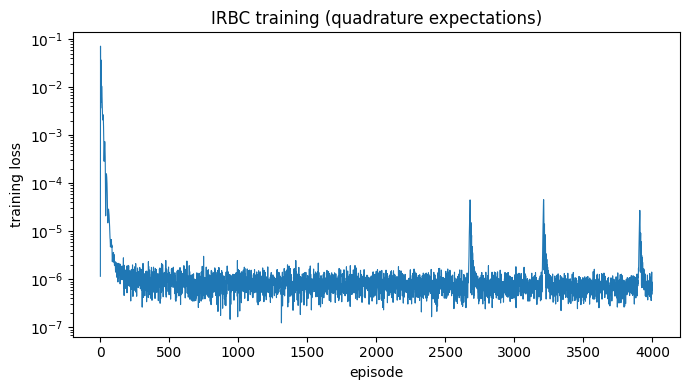

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(history["loss"], lw=0.8)
ax.set_xlabel("episode"); ax.set_ylabel("training loss")
ax.set_title("IRBC training (quadrature expectations)")
fig.tight_layout()

## 4 — Risk sharing: who absorbs the volatility?

Simulate the trained economy and compare consumption volatility across
countries. Efficient risk sharing with $\gamma_0 = 0.25 < \gamma_1 = 1.0$
predicts $\mathrm{std}(\log c_0) \approx 4 \times \mathrm{std}(\log c_1)$:
marginal-utility equalization $\gamma_0\,d\log c_0 = \gamma_1\,d\log c_1$ along
every shock path.

std(log c_0)/std(log c_1) = 4.00   (efficient sharing: gamma_1/gamma_0 = 4.0)


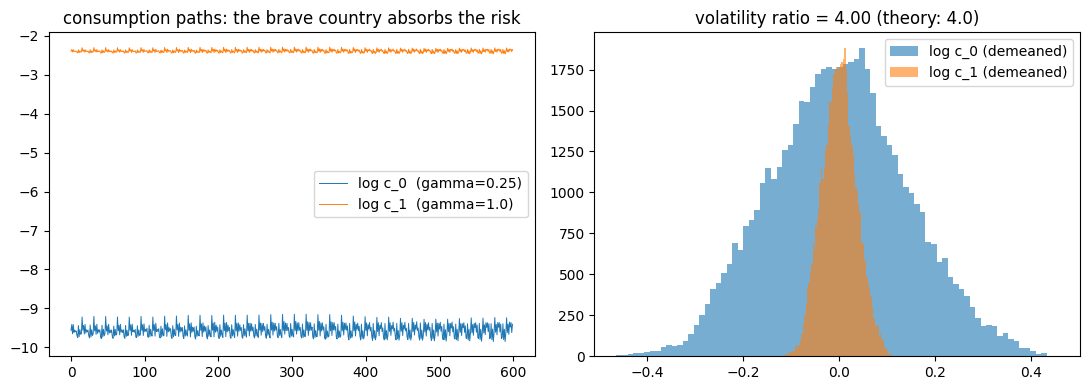

In [4]:
def simulate(net, T=4000, burn=500, n_paths=16, seed=0):
    ss_state, _ = model.steady_state_fn(model.constants)
    s = jnp.tile(jnp.asarray(ss_state)[None, :], (n_paths, 1))
    shocks = jax.random.normal(jax.random.PRNGKey(seed), (T, n_paths, model.n_shocks))
    def step(s, e):
        nxt = model.step_fn(s, net(s), e, model.constants)
        return nxt, nxt
    _, traj = jax.lax.scan(step, s, shocks)
    return traj[burn:]

traj = simulate(params)
states_flat = traj.reshape(-1, model.n_states)
defs = model.definitions_fn(states_flat, params(states_flat), model.constants)

lc0, lc1 = jnp.log(defs["c_0"]), jnp.log(defs["c_1"])
ratio = float(jnp.std(lc0) / jnp.std(lc1))
print(f"std(log c_0)/std(log c_1) = {ratio:.2f}   (efficient sharing: gamma_1/gamma_0 = 4.0)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t = np.arange(600)
axes[0].plot(t, np.asarray(jnp.log(defs["c_0"][:600])), lw=0.7, label="log c_0  (gamma=0.25)")
axes[0].plot(t, np.asarray(jnp.log(defs["c_1"][:600])), lw=0.7, label="log c_1  (gamma=1.0)")
axes[0].set_title("consumption paths: the brave country absorbs the risk")
axes[0].legend()
axes[1].hist(np.asarray(lc0 - lc0.mean()), bins=80, alpha=0.6, label="log c_0 (demeaned)")
axes[1].hist(np.asarray(lc1 - lc1.mean()), bins=80, alpha=0.6, label="log c_1 (demeaned)")
axes[1].set_title(f"volatility ratio = {ratio:.2f} (theory: 4.0)")
axes[1].legend()
fig.tight_layout()

## 5 — Irreversibility: the complementarity L-shape

The defining picture of a learned KKT system: on the ergodic set, every
$(i_j, \mu_j)$ pair must lie on the L — either investment is interior
($i_j > 0,\ \mu_j \approx 0$) or the constraint binds ($i_j \approx 0,\
\mu_j > 0$); never both off zero. At this calibration ($\sigma = 0.01$,
quadratic adjustment costs) irreversibility turns out **never to bind on the
ergodic set** — the validation is that the corner is *respected* ($i_j \ge 0$
everywhere, no negative-investment mass), which the unanchored recipe failed.
Crisis calibrations with larger shocks move mass onto the vertical leg with no
change to the loss.

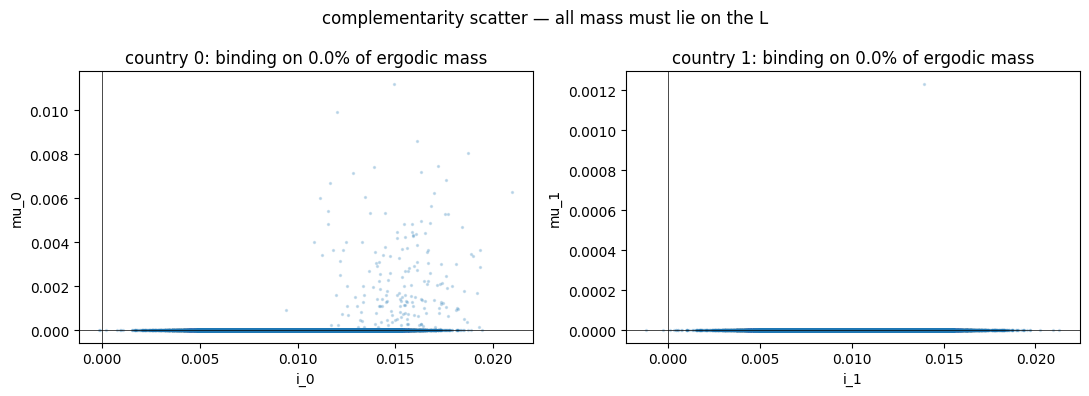

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j, ax in enumerate(axes):
    i_j = np.asarray(defs[f"i_{j}"])
    mu_j = np.asarray(defs[f"mu_{j}"])
    ax.scatter(i_j, mu_j, s=2, alpha=0.2)
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    bind = float((i_j < 1e-4).mean())
    ax.set_xlabel(f"i_{j}"); ax.set_ylabel(f"mu_{j}")
    ax.set_title(f"country {j}: binding on {bind:.1%} of ergodic mass")
fig.suptitle("complementarity scatter — all mass must lie on the L")
fig.tight_layout()

## 6 — Ergodic accuracy certificate

Per-equation residual quantiles on the ergodic set, expectation by the same
27-node quadrature used in training. Eulers are scaled by $\lambda$ (marginal
utility units), the resource constraint by aggregate output; FB residuals are
reported raw (they are already in multiplier units).

In [6]:
from deqn_jax.training.loss import compute_loss, gauss_hermite_nd, compute_residuals

nodes, weights = gauss_hermite_nd(3, model.n_shocks)
sample = states_flat[
    np.random.default_rng(0).choice(states_flat.shape[0], 2048, replace=False)
]

acc = None
for nidx in range(nodes.shape[0]):
    shock = jnp.broadcast_to(jnp.asarray(nodes[nidx])[None, :],
                             (sample.shape[0], model.n_shocks))
    r = compute_residuals(model, params, sample, shock)
    acc = ({k: weights[nidx] * v for k, v in r.items()} if acc is None
           else {k: acc[k] + weights[nidx] * v for k, v in r.items()})

d = model.definitions_fn(sample, params(sample), model.constants)
scale = {
    "euler_0": d["lam"], "euler_1": d["lam"],
    "arc": d["y_0"] + d["y_1"],
    "fb_0": 1.0, "fb_1": 1.0,
}
print(f"{'equation':<10} {'median':>8} {'p90':>8} {'p99':>8}   (log10 |scaled residual|)")
for eq, r in acc.items():
    e = jnp.abs(r) / scale[eq]
    qs = [float(jnp.log10(jnp.maximum(jnp.quantile(e, p), 1e-300)))
          for p in (0.5, 0.9, 0.99)]
    print(f"{eq:<10} {qs[0]:>8.2f} {qs[1]:>8.2f} {qs[2]:>8.2f}")

equation     median      p90      p99   (log10 |scaled residual|)
euler_0       -4.32    -3.76    -3.52
euler_1       -4.36    -3.80    -3.47
arc           -2.89    -2.48    -2.19
fb_0          -6.30    -6.21    -6.16
fb_1          -6.30    -6.21    -6.16


## 7 — Summary

- **Multipliers as policies**: $\lambda,\ \mu_0,\ \mu_1$ are network outputs,
  tied to their constraints by Fischer-Burmeister residuals — the pattern for
  any occasionally-binding constraint whose wedge has no closed form.
- **Structure does the work**: consumption never enters the network; complete
  markets pin it from $\lambda$, and the simulated volatility ratio reproduces
  the $\gamma_1/\gamma_0$ risk-sharing prediction.
- **Quadrature expectations**: with 3 shock dimensions, a 27-node tensor grid
  replaces Monte Carlo — exact expectations, no estimator bias.

**The FB trilogy in this gallery:** `bm_labor_constrained` (analytic wedge,
cap slack by construction) → **`irbc`** (learned multipliers, occasionally
binding) → `olg_lifecycle` (FB wrapping an *expectation*: the two-stage loss).